# Introduction 

You work for the online store Ice, which sells video games worldwide. User and expert reviews, genres, platforms (e.g., Xbox or PlayStation), and historical data on game sales are available from open sources. You need to identify patterns that determine whether a game is successful or not. This will allow you to identify potential hits and plan advertising campaigns.

The available data goes back to 2016. Let's imagine that we are in December 2016 and you are planning a campaign for 2017.

The important thing is to gain experience working with data. It doesn't matter if you are predicting 2017 sales based on 2016 data or 2027 sales based on 2026 data.

The dataset contains a "rating" column that stores the ESRB rating of each game. The Entertainment Software Rating Board evaluates a game's content and assigns an age rating, such as Teen or Mature.

## Data Dictionary

— Name 

— Platform 

— Year_of_Release 

— Genre 

— NA_sales (North American sales in millions of USD)

— EU_sales (Sales in Europe in millions of USD)

— JP_sales (Sales in Japan in millions of USD)

— Other_sales (Sales in other countries in millions of USD)

— Critic_Score  (maximum de 100)

— User_Score (minimum de 10)

— Classification (ESRB)

The 2016 data may be incomplete.

In [12]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st

In [13]:
df_games = pd.read_csv('../data/games.csv')

# Data Preparation

In [14]:
# Substituindo o nome das colunas para minúsculos 
# Convertendo os dados para os tipos necessario.

df_games.columns = df_games.columns.str.lower()
df_games['year_of_release'] = pd.to_numeric(df_games['year_of_release'], errors='coerce').astype('Int64')
df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce')

df_games.info()
df_games.sample(5)

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
dtypes: Int64(1), float64(6), str(4)
memory usage: 1.4 MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
14102,Warhammer: The End Times - Vermintide,PS4,2016,Action,0.01,0.02,0.00,0.01,NaN,NaN,NaN
3171,X-Men Legends II: Rise of Apocalypse,PS2,2005,Role-Playing,0.53,0.02,0.00,0.09,82.0,7.3,T
14449,Fullmetal Alchemist: Brotherhood,PSP,<NA>,Action,0.00,0.00,0.03,0.00,NaN,NaN,NaN
9284,Rio,PS3,2011,Misc,0.04,0.07,0.00,0.02,65.0,NaN,E10+
10670,Bleach: Dark Souls (JP sales),DS,2007,Fighting,0.00,0.00,0.10,0.00,NaN,NaN,NaN


## Descricao da alteracao dos tipos de dados: 

- year_of_release: convertido do tipo string para inteiro. Os anos de lancamentos sao numeros inteiros e nao faz sentido trata-los como string. 
- user_score: convertido do tipo string para numerico. Esta coluna tem avaliacoes numericas mas foi identificada como string devido a presenca da string "TBD". Transformamos para numerico passando "TBD" em valores nulos para efetuar calculos futuros.

### Finding missing values ​​/ Replacing rating with "Undefined"

In [15]:
df_games['rating'] = df_games['rating'].fillna('Indefinido')

print(df_games.isna().sum())

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating                0
dtype: int64


### Calculating the total sales for all regions and placing them in a separate column.

In [16]:
df_games['total_sales'] = df_games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

df_games.head(5)


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,Indefinido,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,Indefinido,31.38


# EDA - Data Analysis

### See how many games were released each year. Is the data for each period significant?

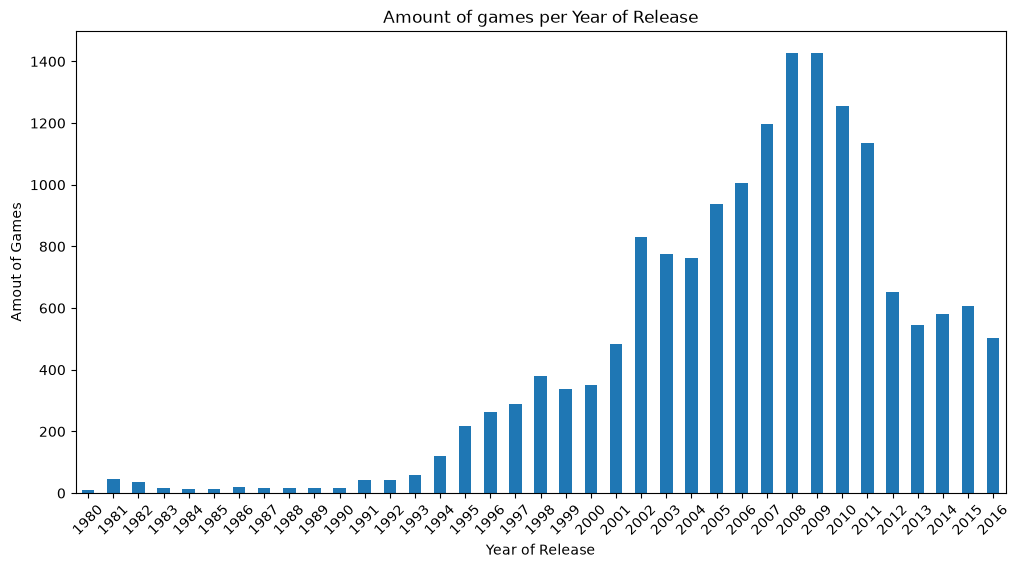

In [17]:

games_per_year = df_games.groupby('year_of_release')['name'].count()

games_per_year.plot(kind='bar', figsize=(12,6), rot=45)

plt.title('Amount of games per Year of Release')
plt.xlabel('Year of Release')
plt.ylabel('Amout of Games')
plt.show()

- We observe that, prior to the 1990s and 2000s, the volume of games was very low. Therefore, data from the last century is not significant for predicting the modern gaming market. Growth began in the 2000s.

### See how sales varied from platform to platform. Select the platforms with the highest total sales and build a distribution based on the data for each year. Identify platforms that used to be popular but now have no sales. How long does it take for new platforms to emerge and old ones to disappear?

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
Name: total_sales, dtype: float64


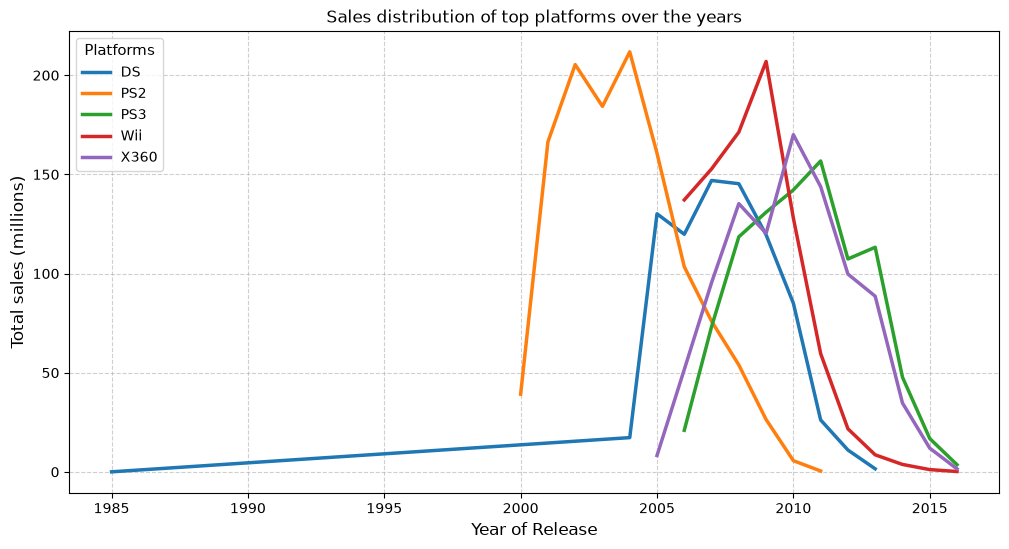

In [24]:
top_platforms = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5)
print(top_platforms)

top_platforms_names = top_platforms.index
df_top = df_games[df_games['platform'].isin(top_platforms_names)]

platform_sales_by_year = df_top.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum')

plt.figure(figsize=(12,6))
sns.lineplot(platform_sales_by_year, dashes=False, linewidth=2.5)

plt.title('Sales distribution of top platforms over the years')
plt.ylabel('Total sales (millions)', fontsize=12)
plt.xlabel('Year of Release', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title='Platforms', title_fontsize='11', loc='upper left')
plt.show()

- Looking at platforms that lost popularity, we can see that massive consoles like the PS2 and Wii experienced huge sales peaks (surpassing 200 million units sold), yet by 2016, their sales had dropped to virtually zero. The same obsolescence affected the DS, Xbox 360, and PS3 leading up to 2016.
- Regarding platform lifecycles—specifically the rise and fall of each console—we can estimate that it takes an average of about five years to reach peak performance after launch, while the total lifecycle of a popular platform (from its debut to its complete disappearance from the market) lasts approximately ten years.

- Since console lifecycles last around 10 years and sales of older platforms plummeted drastically between 2011 and 2013 with the arrival of the new generation, older data is not useful for predicting the current market. Therefore, the relevant period for analysis will be 2013 to 2016. 

### Which platforms are leading in sales? Which ones are growing or declining? Select several potentially profitable platforms.

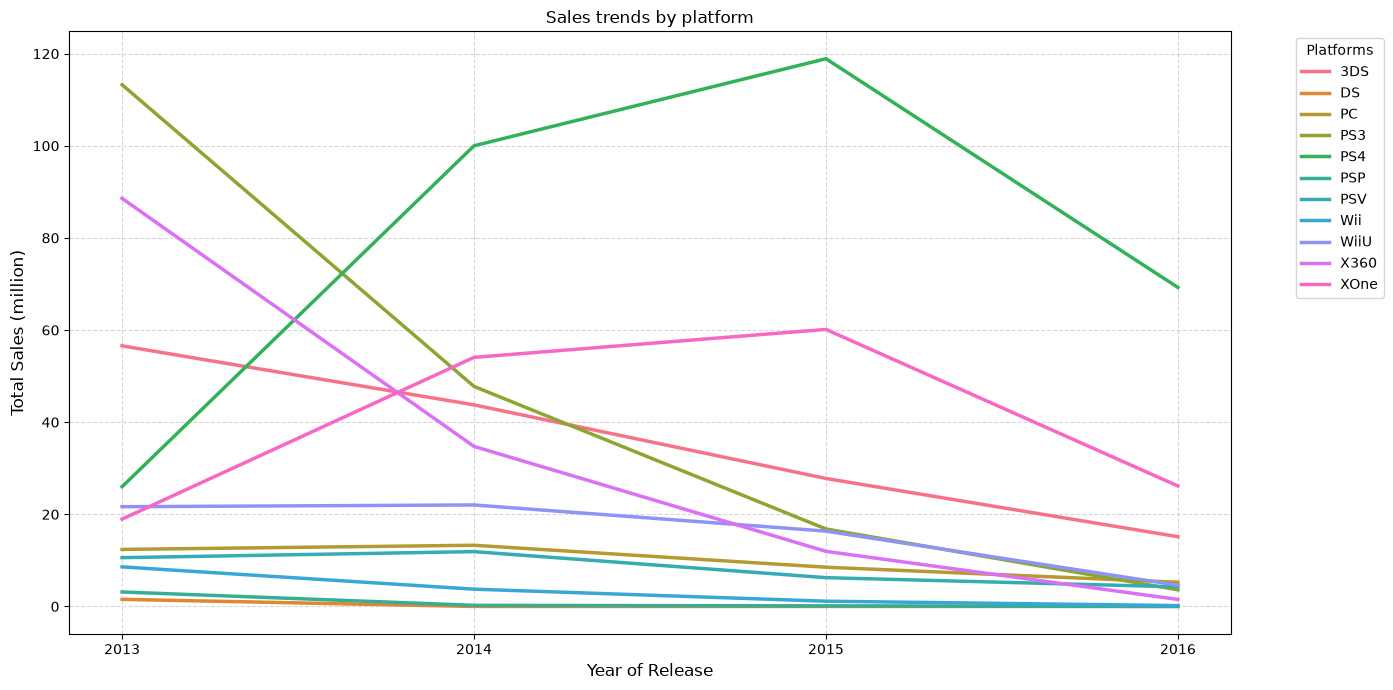

Total accumulated sales by platform (2013 - 2016):
platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64


In [20]:
df_relevant = df_games[df_games['year_of_release'] >= 2013]

sales_by_year_recent = df_relevant.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
).fillna(0)

plt.figure(figsize=(14,7))
sns.lineplot(data=sales_by_year_recent, dashes=False, linewidth=2.5)

plt.title('Sales trends by platform')
plt.ylabel('Total Sales (million)', fontsize=12)
plt.xlabel('Year of Release', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks([2013, 2014, 2015, 2016])

plt.legend(title='Platforms', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

print('Total accumulated sales by platform (2013 - 2016):')
print(df_relevant.groupby('platform')['total_sales'].sum().sort_values(ascending=False))

- As shown in the graph, the PS4 is the clear sales leader for this recent period, peaking at over 120 million annual sales in 2015. The Xbox One ranks second, remaining well ahead of the other platforms.
- The PS3 and Xbox 360 show a sharp decline; they started 2013 very strongly but plummeted to near-zero levels by 2016. This illustrates the generational transition, as players moved away from older consoles. The overall trend for 2016 shows a decline across all lines.
- The most promising platforms for investment focus are the PS4, Xbox One, and 3DS.

### Create a box plot for the global sales of all games, broken down by platform. Are the differences in sales significant? What about the average sales across the various platforms? Describe your findings.

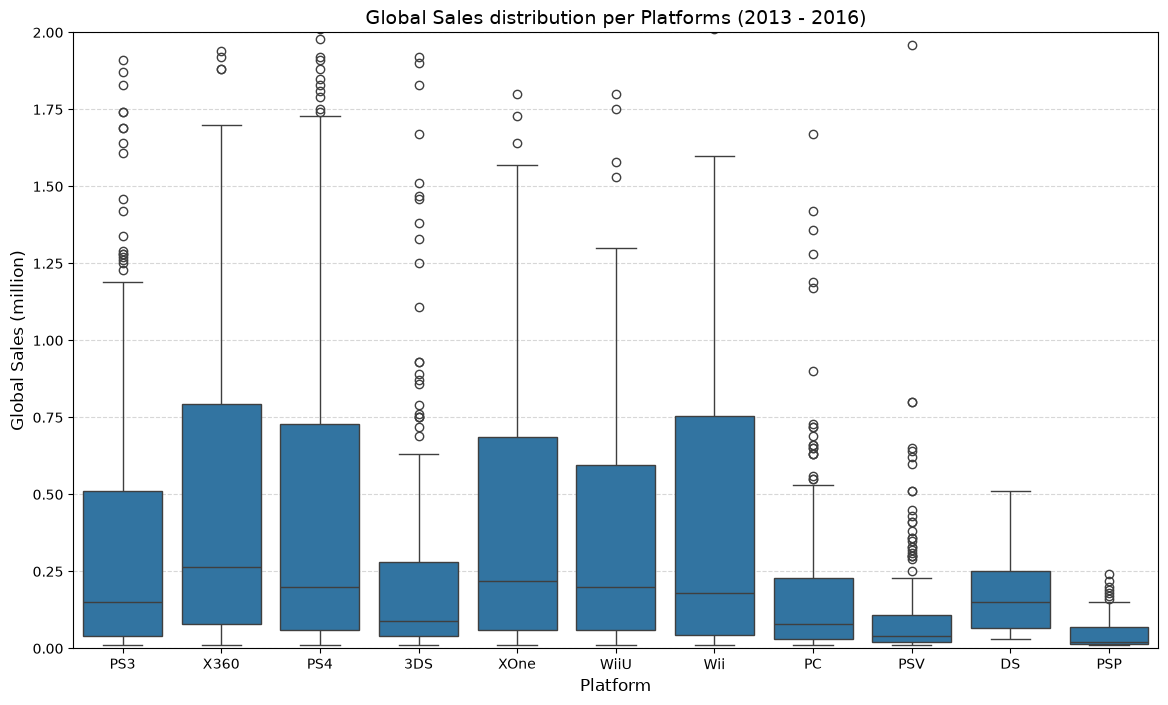

In [ ]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=df_relevant, x='platform', y='total_sales')

plt.title('Global Sales distribution per Platforms (2013 - 2016)', fontsize=14)
plt.ylabel('Global Sales (million)', fontsize=12)
plt.xlabel('Platform', fontsize=12)
plt.ylim(0, 2)

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

- Based on the box plot, the differences in sales are highly significant. There is a clear divide between the performance of major home consoles and that of handheld devices and the PC. Platforms such as the X360, PS4, XOne, and Wii feature much taller and longer boxes, indicating that the overall volume of copies sold per game on these platforms is significantly higher. In contrast, consoles like the PSV and PSP have flattened, low boxes, demonstrating that the vast majority of their games sell very few copies.
- The medians for the X360, PS4, and XOne are positioned very similarly. This indicates that the typical sales pattern for a game released on this category of console is statistically comparable. Meanwhile, the PC and 3DS show low medians but exhibit a vast number of outliers.

### Create a scatter plot and calculate the correlation between ratings and sales.

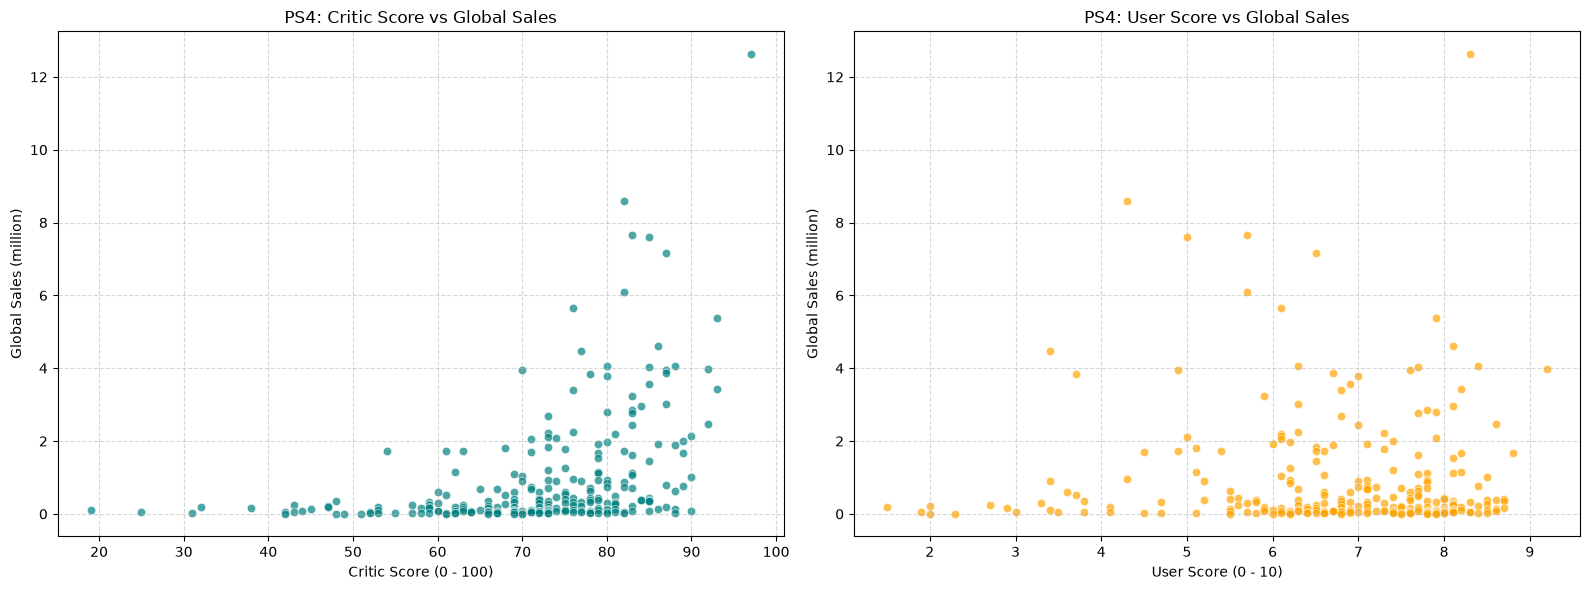

Correlation between critic scores and PS4 sales: 0.41
Correlation between user scores and PS4 sales: -0.03


In [ ]:
df_relevant['user_score'] = pd.to_numeric(df_relevant['user_score'], errors='coerce')
df_relevant['critic_score'] = pd.to_numeric(df_relevant['critic_score'], errors='coerce')

df_PS4 = df_relevant[df_relevant['platform'] == 'PS4']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_PS4, x='critic_score', y='total_sales', alpha=0.7, ax=axes[0], color='teal')
axes[0].set_title('PS4: Critic Score vs Global Sales')
axes[0].set_xlabel('Critic Score (0 - 100)')
axes[0].set_ylabel('Global Sales (million)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df_PS4, x='user_score', y='total_sales', alpha=0.7, ax=axes[1], color='orange')
axes[1].set_title('PS4: User Score vs Global Sales')
axes[1].set_xlabel('User Score (0 - 10)')
axes[1].set_ylabel('Global Sales (million)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

corr_critic = df_PS4['critic_score'].corr(df_PS4['total_sales'])
corr_user = df_PS4['user_score'].corr(df_PS4['total_sales'])

print(f"Correlation between critic scores and PS4 sales: {corr_critic:.2f}")
print(f"Correlation between user scores and PS4 sales: {corr_user:.2f}")

### Compare the sales of the same games on other platforms.

Sales Comparison the same games per platform (in million):
platform                          PC    PS3    PS4   X360  XOne
name                                                           
Call of Duty: Advanced Warfare  0.41   4.36   7.66   4.28  5.26
Call of Duty: Black Ops 3       0.26   1.69  14.63   1.70  7.39
FIFA 16                         0.20   2.70   8.58   1.57  3.25
Grand Theft Auto V              1.17  21.05  12.62  16.27  5.47
Star Wars Battlefront (2015)    0.55   0.00   7.98   0.00  3.66


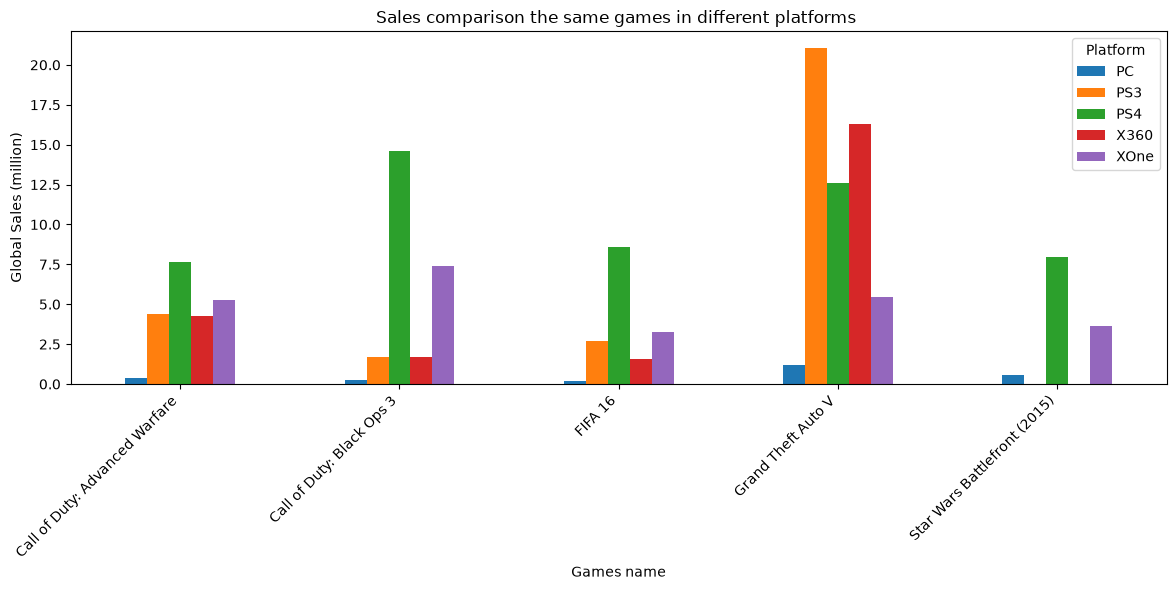

In [ ]:
top_ps4_games = df_relevant[df_relevant['platform'] == 'PS4'].sort_values(by='total_sales', ascending=False)['name'].head(5)

df_comparison = df_relevant[df_relevant['name'].isin(top_ps4_games)]

game_platform_sales = df_comparison.pivot_table(
    index='name', 
    columns='platform',
    values='total_sales'
).fillna(0)

print('Sales Comparison the same games per platform (in million):')
print(game_platform_sales)

game_platform_sales.plot(kind='bar', figsize=(12,6))
plt.title('Sales comparison the same games in different platforms ')
plt.ylabel('Global Sales (million)')
plt.xlabel('Games name')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Platform')
plt.tight_layout()
plt.show()

- The performance of the same game varies drastically depending on the title's release year and the size of each console's active user base at that specific time.

### Take a look at the overall distribution of games by genre. What can we say about the most profitable genres? Can you make generalizations about genres with high and low sales?

General analysis by genre (2013–2016):
                 sum  median  count
genre                              
Shooter       232.98   0.450    187
Sports        150.65   0.240    214
Platform       42.63   0.225     74
Role-Playing  145.89   0.125    292
Fighting       35.31   0.125     80
Racing         39.89   0.120     85
Action        321.87   0.110    766
Simulation     21.76   0.100     62
Misc           62.82   0.100    155
Strategy       10.08   0.080     56
Puzzle          3.17   0.060     17
Adventure      23.64   0.030    245


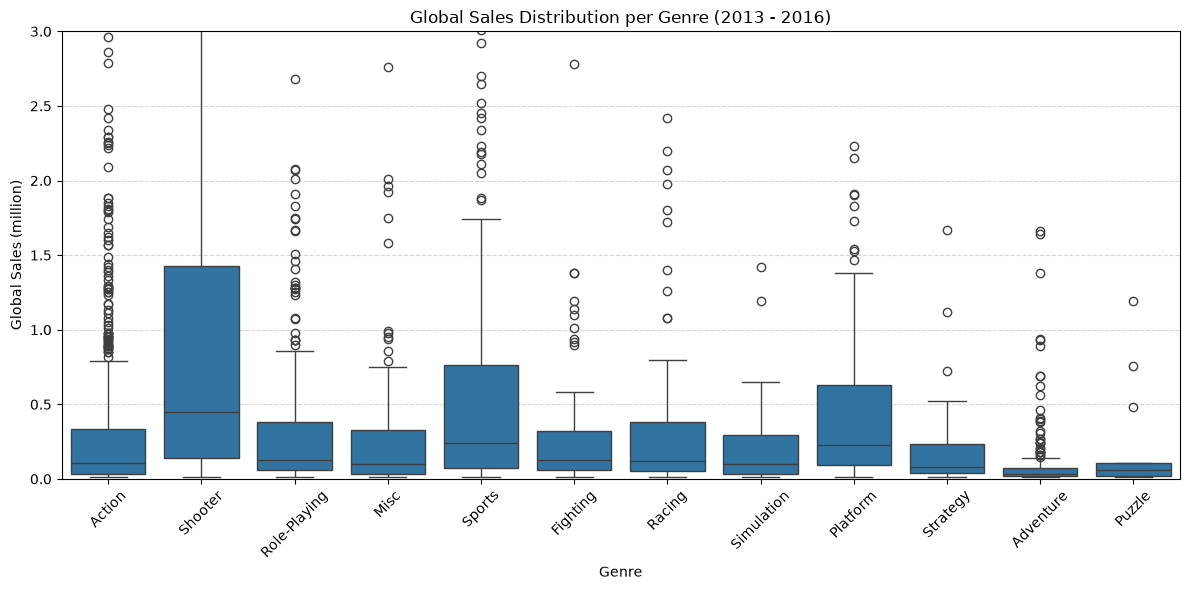

In [ ]:
genre_analysis = df_relevant.groupby('genre')['total_sales'].agg(['sum', 'median', 'count']).sort_values(by='median', ascending=False)
print("General analysis by genre (2013–2016):")
print(genre_analysis)

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_relevant, x='genre', y='total_sales')
plt.title('Global Sales Distribution per Genre (2013 - 2016)')
plt.ylabel('Global Sales (million)')
plt.xlabel('Genre')
plt.ylim(0, 3)
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


- We can see from the diagram that the most profitable genre is Shooter. Its median is close to 50 million, whereas most other genres struggle to surpass 20 million.
- Sports and Platform games have excellent medians and well-distributed box plots, indicating a loyal audience and robust sales per title.
- Note that the Action genre has a low median and is heavily populated with outliers; this means that while many action games are released, the vast majority sell very few copies, with the genre being sustained by a few super-hits. Therefore, it is not a consistently profitable genre.

# Create a user profile for each region.

### The five main platforms. Describe the variations in their market shares from region to region.

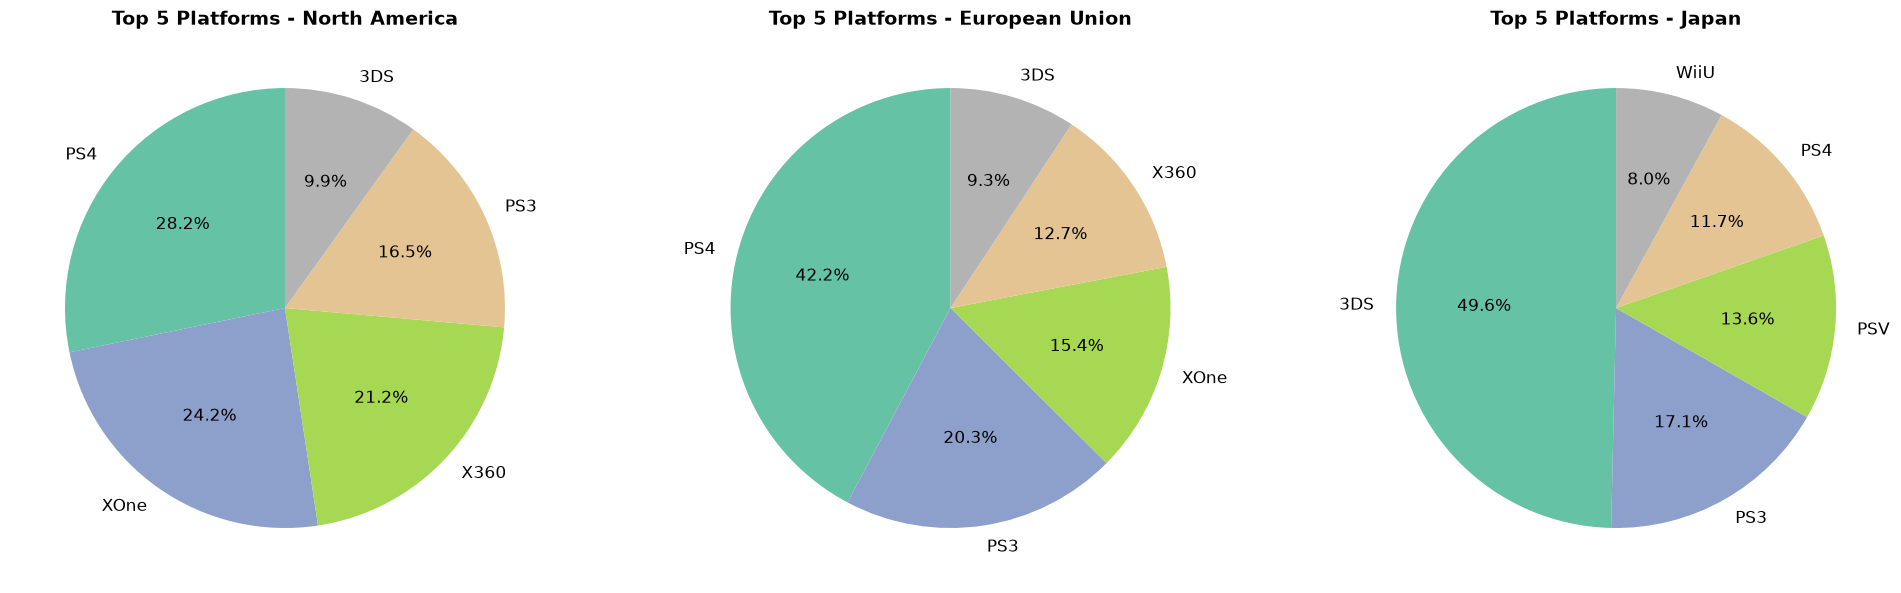

In [21]:
regions = ['na_sales', 'eu_sales', 'jp_sales']
titles = ['Top 5 Platforms - North America', 'Top 5 Platforms - European Union', 'Top 5 Platforms - Japan']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, region in enumerate(regions):
    top_platforms_region = df_relevant.groupby('platform')[region].sum().sort_values(ascending=False).head(5)

    top_platforms_region.plot(kind='pie', autopct='%1.1f%%', ax=axes[i], startangle=90,
                              cmap='Set2', textprops={'fontsize': 12})
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

North America
- It is a highly competitive market between the PS4 (28.2%) and the XOne (24.2%). Notably, the X360 (21.2%) and PS3 (16.5%) still hold significant market shares.

European Union
- Preference leans toward the PS4 (42.2%), with the PS3 (20.3%) in second place and the XOne (15.4%) in third.

Japan
- Japanese consumers prefer handheld consoles, with the 3DS (49.6%) leading the pack. Notably, Xbox consoles (One/360) do not even appear in the rankings. The market is 100% dominated by local brands: Nintendo and Sony.

### The five main genres. Explain the difference.

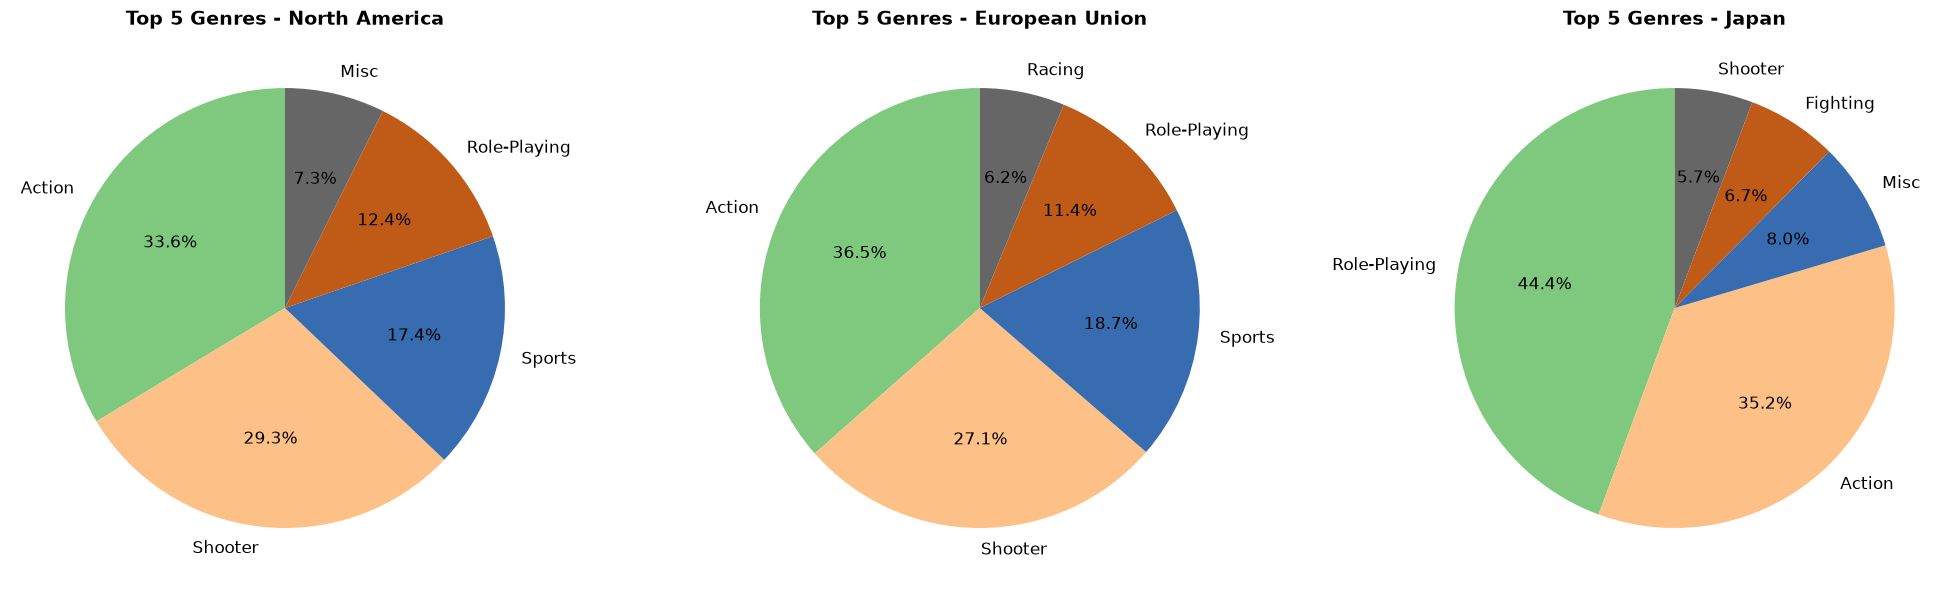

In [23]:
titles_genres = ['Top 5 Genres - North America', 'Top 5 Genres - European Union', 'Top 5 Genres - Japan']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, region in enumerate(regions):
    top_genres_region = df_relevant.groupby('genre')[region].sum().sort_values(ascending=False).head(5)

    top_genres_region.plot(kind='pie', autopct='%1.1f%%', ax=axes[i], startangle=90,
                              cmap='Accent', textprops={'fontsize': 12})
    axes[i].set_title(titles_genres[i], fontsize=14, fontweight='bold')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

- North America and the European Union share similar gaming preferences, with action and shooter titles dominating the rankings; together, they account for over 60% of the entire Western market. The sports genre consistently holds the third spot in both regions.

- In Japan, however, the role-playing genre is the undisputed leader, commanding 44.4% of all sales in the country. This makes perfect historical and cultural sense, as major Japanese RPG franchises are national sensations that pair perfectly with handheld consoles. The action genre ranks second, whereas the shooter genre—a market leader in the West—holds only a modest share in Japan. 

### Do ESRB ratings affect sales in individual regions?

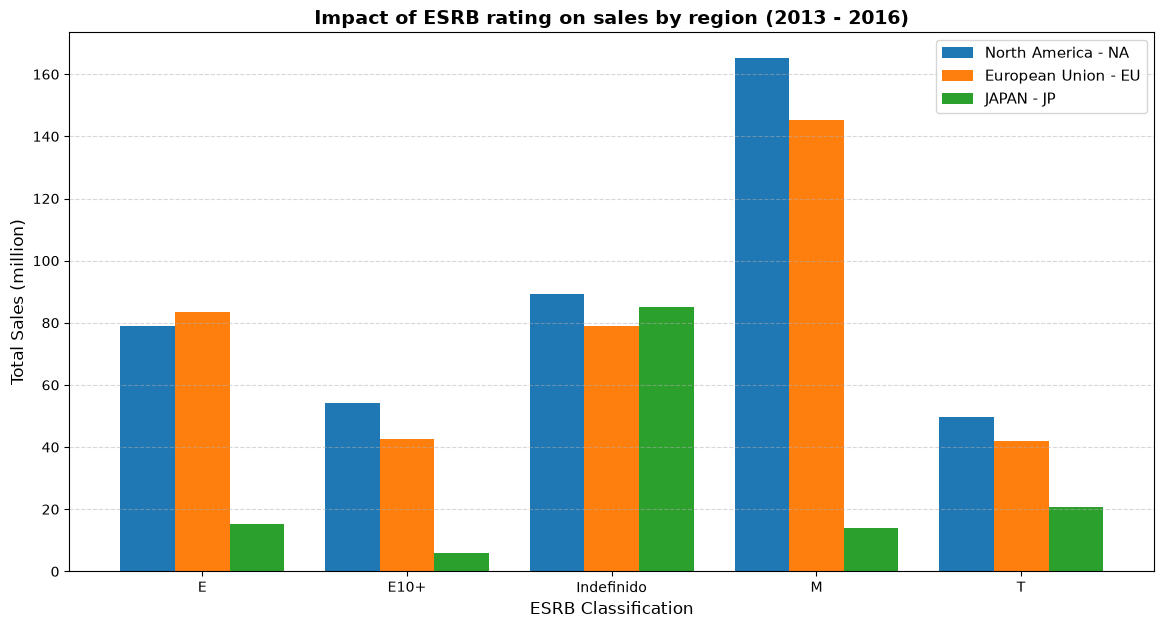

In [ ]:
esrb_analysis = df_relevant.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()

esrb_analysis.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title('Impact of ESRB rating on sales by region (2013 - 2016)', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales (million)', fontsize=12)
plt.xlabel('ESRB Classification', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(['North America - NA', 'European Union - EU', 'JAPAN - JP'], fontsize=11)

plt.show()

- "Mature" (M-rated) games are by far the best-selling category in both regions. This aligns with the earlier finding that Western markets favor shooter and action games—genres that almost invariably receive an M rating. Meanwhile, games rated "E" (Everyone) and those with undefined ratings follow close behind as stable secondary segments.
- In Japan, however, the bar reaches its absolute peak in the "undefined" category. This is because the ESRB is a North American body, whereas Japan has its own regulatory agency, CERO. Since many RPGs and niche titles targeting the Japanese handheld market are produced by local studios—and often never officially released in the US—they do not receive an ESRB rating.
- Japan accounts for a minuscule share of M-rated game consumption. This confirms that the Japanese audience prefers games with aesthetics geared toward all ages or teenagers, shunning violent Western shooters.

# Hypotheses Test

### The average user ratings for the Xbox One and PC platforms are the same.

In [ ]:
xbox_one_ratings = df_relevant[df_relevant['platform'] == 'XOne']['user_score'].dropna()
pc_ratings = df_relevant[df_relevant['platform'] == 'PC']['user_score'].dropna()

print(f"Average of user score in Xbox One: {xbox_one_ratings.mean():.2f}")
print(f"Average of user score in PC: {pc_ratings.mean():.2f}")
print("-" * 50)

alpha = 0.05

results = st.ttest_ind(xbox_one_ratings, pc_ratings, equal_var=False)

print(f"P - Value: {results.pvalue}")

if results.pvalue < alpha:
    print('We reject the null hypothesis: The average user ratings are different.')
else:
    print('We cannot reject the null hypothesis: there is not enough evidence to say that the means are different.')

Average of user score in Xbox One: 6.52
Average of user score in PC: 6.27
--------------------------------------------------
P - Value: 0.1475959401343046
We cannot reject the null hypothesis: there is not enough evidence to say that the means are different.


- Since the p-value was approximately 0.15—considerably higher than the alpha threshold—we reach the statistically correct conclusion that we cannot reject the null hypothesis. In other words, the average user ratings for the XOne and PC are statistically equivalent, and the small difference observed is due solely to sampling chance.

### The average user ratings for the Action and Sports genres are different.

In [ ]:
action_ratings = df_relevant[df_relevant['genre'] == 'Action']['user_score'].dropna()
sports_ratings = df_relevant[df_relevant['genre'] == 'Sports']['user_score'].dropna()

print(f"Average of user score in Action: {action_ratings.mean():.2f}")
print(f"Average of user score in Sports: {sports_ratings.mean():.2f}")
print("-" * 50)

alpha = 0.05

results = st.ttest_ind(action_ratings, sports_ratings, equal_var=False)

print(f"P - Value: {results.pvalue}")

if results.pvalue < alpha:
    print('We reject the null hypothesis: The average user ratings are different.')
else:
    print('We cannot reject the null hypothesis: there is not enough evidence to say that the means are different.')

Average of user score in Action: 6.84
Average of user score in Sports: 5.24
--------------------------------------------------
P - Value: 1.4460039700703936e-20
We reject the null hypothesis: The average user ratings are different.


- Since the p-value was close to zero and significantly lower than the alpha threshold—we reached the statistically valid conclusion that the null hypothesis can be rejected. In other words, there is a very strong, statistically significant difference between user opinions on action games and sports games.

- In both cases, the null hypothesis was formulated based on the principle of equality, while the alternative hypothesis reflected the premise we sought to test. I used Student's t-test for independent samples, as we were comparing the means of two distinct and independent statistical populations. Furthermore, we set `equal_var=False` because the sample sizes and variances of the analyzed groups were not strictly equal. An alpha value of 0.05 was used.

# Geral Conclusion

Data analysis made it possible to identify the key factors linked to the commercial success of games and to understand how the market has evolved over the years. It was observed that platform lifecycles are relatively short, making more recent data (2013–2016) more relevant for market projections.

Among the platforms, the PS4, Xbox One, and Nintendo 3DS showed the greatest investment potential for 2017, whereas consoles from previous generations—such as the PS3, Xbox 360, Wii, and DS—showed a sharp decline in sales. It was also found that genres like Shooter and Sports achieve better average sales performance, although the Action genre accounts for some of the biggest commercial hits, despite significant variability among its titles.

Regional analysis revealed significant differences in consumer behavior. North America and Europe share similar preferences—favoring action and shooter games—while Japan shows a strong preference for RPGs and handheld consoles, highlighting distinct cultural characteristics that should be taken into account in launch and marketing strategies.

Statistical tests reinforced these conclusions, indicating no significant difference between user ratings for Xbox One and PC games, but a statistically significant difference between ratings for the Action and Sports genres.

Overall, the project demonstrated how exploratory data analysis and statistical testing can transform historical data into actionable insights for decision-making. These results can assist companies in shaping advertising campaigns, selecting priority platforms, and identifying genres with the greatest potential for success in the gaming market.